# NDN Anomaly Detection — Per-Topology Models

This notebook trains **one Isolation Forest per topology** (Tree, Dumbbell, DFN), tests each model on its own IFA attack data, and then compares per-topology results against a **global model** trained on all topologies combined.

**Key question:** Does specialising the model per topology improve per-node detection rates and reduce false positives on benign nodes?

Structure:
1. Train per-topology models (clip bounds, scaler, Isolation Forest)
2. Per-node detection comparison: per-topology vs global
3. Z-score heatmaps using each topology's own scaler
4. Score distributions: global vs per-topology
5. Attacker node (c1) score timeline comparison
6. Summary detection table

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "research_analysis" else Path.cwd()
LOGS_DIR     = PROJECT_ROOT / "Datacard" / "Logs"
FIG_DIR      = PROJECT_ROOT / "research_analysis" / "figures" / "per_topo"
RES_DIR      = PROJECT_ROOT / "research_analysis" / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature names ──────────────────────────────────────────────────────────
FEATURES = [
    "pit_size", "pit_growth_rate", "cs_size", "cache_hit_ratio",
    "satisfaction_ratio", "unsatisfied_ratio",
    "in_interests_rate", "out_interests_rate", "in_data_rate", "nack_rate",
]
FEAT_LABELS = [
    "PIT size", "PIT growth", "CS size", "Cache hit",
    "Sat ratio", "Unsat ratio",
    "InInt rate", "OutInt rate", "InData rate", "NACK rate",
]

# ── Node colour coding ─────────────────────────────────────────────────────
NODE_COLORS = {
    "consumer":   "#4c72b0",
    "router":     "#dd8452",
    "producer":   "#55a868",
    "bottleneck": "#8172b2",
}

ATTACKER = "c1"

# ── Topology definitions ───────────────────────────────────────────────────
TOPOLOGIES = {
    "tree": {
        "normal_datasets": ["tree_normal_1", "tree_normal_2"],
        "attack_dataset":  "tree_ifa",
        "nodes": ["c1","c2","c3","c4","c5","c6","p1","p2","r1","r2","r3","r4"],
    },
    "dumbbell": {
        "normal_datasets": ["dumbbell_normal"],
        "attack_dataset":  "dumbbell_ifa",
        "nodes": ["c1","c2","c3","p1","p2","r1","r2","r3","r4","bottleneck"],
    },
    "dfn": {
        "normal_datasets": ["dfn_normal"],
        "attack_dataset":  "dfn_ifa",
        "nodes": ["c1","c2","c3","c4","c5","c6","p1","p2","r1","r2","r3","r4"],
    },
}

# ── Node type helpers ──────────────────────────────────────────────────────
def node_type(node: str) -> str:
    n = node.lower()
    if n.startswith("c"):          return "consumer"
    if n.startswith("p"):          return "producer"
    if n == "bottleneck":          return "bottleneck"
    return "router"

def node_order(node: str) -> tuple:
    """Sort key: type bucket then numeric suffix."""
    order = {"consumer": 0, "producer": 1, "router": 2, "bottleneck": 3}
    t = node_type(node)
    suffix = "".join(filter(str.isdigit, node))
    return (order[t], int(suffix) if suffix else 999)

def sorted_nodes(nodes):
    return sorted(nodes, key=node_order)

# ── Feature computation ────────────────────────────────────────────────────
def compute_features(base_path: Path) -> pd.DataFrame:
    """Load all *.jsonl recursively under base_path, sort by node+timestamp,
    compute per-interval delta features."""
    records = []
    for fp in sorted(base_path.rglob("*.jsonl")):
        with open(fp) as fh:
            for line in fh:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["node", "timestamp"]).reset_index(drop=True)

    rows = []
    for node, grp in df.groupby("node", sort=False):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        for i in range(1, len(grp)):
            prev, curr = grp.iloc[i-1], grp.iloc[i]
            dt = max((curr.timestamp - prev.timestamp).total_seconds(), 1e-6)

            d_pit   = curr.nPitEntries - prev.nPitEntries
            d_hits  = curr.nHits  - prev.nHits
            d_miss  = curr.nMisses - prev.nMisses
            d_sat   = curr.nSatisfiedInterests   - prev.nSatisfiedInterests
            d_unsat = curr.nUnsatisfiedInterests - prev.nUnsatisfiedInterests
            d_ini   = curr.nInInterests  - prev.nInInterests
            d_outi  = curr.nOutInterests - prev.nOutInterests
            d_ind   = curr.nInData       - prev.nInData
            d_nack  = (curr.nInNacks + curr.nOutNacks) - (prev.nInNacks + prev.nOutNacks)

            cache_denom = d_hits + d_miss
            sat_denom   = d_sat  + d_unsat

            rows.append({
                "node":               node,
                "timestamp":          curr.timestamp,
                "pit_size":           float(curr.nPitEntries),
                "pit_growth_rate":    float(d_pit) / dt,
                "cs_size":            float(curr.nCsEntries),
                "cache_hit_ratio":    float(d_hits) / cache_denom if cache_denom > 0 else 0.0,
                "satisfaction_ratio": float(d_sat)  / sat_denom   if sat_denom   > 0 else 0.0,
                "unsatisfied_ratio":  float(d_unsat) / sat_denom  if sat_denom   > 0 else 0.0,
                "in_interests_rate":  max(float(d_ini),  0.0) / dt,
                "out_interests_rate": max(float(d_outi), 0.0) / dt,
                "in_data_rate":       max(float(d_ind),  0.0) / dt,
                "nack_rate":          max(float(d_nack), 0.0) / dt,
            })

    return pd.DataFrame(rows)

# ── Clip bounds & normalisation helpers ───────────────────────────────────
def apply_clip(df: pd.DataFrame, clip_bounds: dict) -> pd.DataFrame:
    df = df.copy()
    for feat, bounds in clip_bounds.items():
        if feat in df.columns:
            df[feat] = df[feat].clip(bounds["lo"], bounds["hi"])
    return df

def make_normalizer(scores: np.ndarray, theta: float = 0.0):
    """Return a function that maps raw IF scores → [0, 100] normalised scores."""
    s_min = float(scores.min())
    s_max = float(scores.max())

    def normalise(s: np.ndarray) -> np.ndarray:
        out = np.empty_like(s, dtype=float)
        above = s >= theta
        below = ~above
        # above threshold: map [theta, s_max] → [30, 100]
        denom_above = s_max - theta
        if denom_above > 1e-12:
            out[above] = 30.0 + (s[above] - theta) / denom_above * 70.0
        else:
            out[above] = 30.0
        # below threshold: map [s_min, theta] → [0, 30)
        denom_below = theta - s_min
        if denom_below > 1e-12:
            out[below] = 30.0 * (s[below] - s_min) / denom_below
        else:
            out[below] = 0.0
        return np.clip(out, 0.0, 100.0)

    return normalise, s_min, s_max


print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"LOGS_DIR     : {LOGS_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")
print(f"RES_DIR      : {RES_DIR}")

PROJECT_ROOT : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN
LOGS_DIR     : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/Datacard/Logs
FIG_DIR      : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/per_topo
RES_DIR      : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/results


## 1. Training Per-Topology Models

In [3]:
models = {}

for topo, cfg in TOPOLOGIES.items():
    print(f"\n{'='*60}")
    print(f"  Topology: {topo.upper()}")
    print(f"{'='*60}")

    # ── Load all normal datasets for this topology ─────────────────────────
    dfs_normal = []
    for ds_name in cfg["normal_datasets"]:
        ds_path = LOGS_DIR / ds_name
        if not ds_path.exists():
            print(f"  [WARN] {ds_path} not found, skipping")
            continue
        df_tmp = compute_features(ds_path)
        if not df_tmp.empty:
            dfs_normal.append(df_tmp)
            print(f"  Loaded {len(df_tmp):>6,} rows from {ds_name}")

    if not dfs_normal:
        print(f"  [ERROR] No normal data for {topo}, skipping.")
        continue

    df_normal = pd.concat(dfs_normal, ignore_index=True)
    print(f"  Total normal samples: {len(df_normal):,}")

    # ── Compute per-topology clip bounds (P1 / P99 on normal) ──────────────
    clip_bounds = {}
    for feat in FEATURES:
        lo = float(np.percentile(df_normal[feat].dropna(), 1))
        hi = float(np.percentile(df_normal[feat].dropna(), 99))
        if hi > lo:
            clip_bounds[feat] = {"lo": lo, "hi": hi}

    # ── Apply clip bounds ──────────────────────────────────────────────────
    df_normal_clipped = apply_clip(df_normal, clip_bounds)
    X_normal = df_normal_clipped[FEATURES].fillna(0.0).values

    # ── Train pipeline ─────────────────────────────────────────────────────
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("if",     IsolationForest(
            n_estimators=200,
            contamination=0.01,
            random_state=42,
        )),
    ])
    pipe.fit(X_normal)

    # ── Compute training scores & normalisation params ─────────────────────
    raw_scores_normal = pipe.decision_function(X_normal)          # higher = more normal
    theta = 0.0
    normalise, s_min, s_max = make_normalizer(raw_scores_normal, theta)
    norm_scores_normal = normalise(raw_scores_normal)

    fpr_30 = (norm_scores_normal < 30).mean()
    fpr_50 = (norm_scores_normal < 50).mean()
    print(f"  Training FPR @30: {fpr_30:.2%}  |  FPR @50: {fpr_50:.2%}")

    # ── Store model artefacts ──────────────────────────────────────────────
    models[topo] = {
        "pipe":         pipe,
        "threshold":    theta,
        "score_min":    s_min,
        "score_max":    s_max,
        "normalizer":   normalise,
        "clip_bounds":  clip_bounds,
        "df_normal":    df_normal,
    }

print("\nPer-topology model training complete.")


  Topology: TREE


  Loaded 12,912 rows from tree_normal_1


  Loaded  6,033 rows from tree_normal_2
  Total normal samples: 18,945


  Training FPR @30: 1.00%  |  FPR @50: 3.82%

  Topology: DUMBBELL


  Loaded 18,981 rows from dumbbell_normal
  Total normal samples: 18,981


  Training FPR @30: 1.00%  |  FPR @50: 4.05%

  Topology: DFN


  Loaded 16,963 rows from dfn_normal
  Total normal samples: 16,963


  Training FPR @30: 1.00%  |  FPR @50: 4.82%

Per-topology model training complete.


In [4]:
# ── Score IFA datasets with per-topology models ────────────────────────────
all_pertopo_rows = []

for topo, cfg in TOPOLOGIES.items():
    if topo not in models:
        continue

    m        = models[topo]
    pipe     = m["pipe"]
    normalise = m["normalizer"]
    bounds   = m["clip_bounds"]

    atk_path = LOGS_DIR / cfg["attack_dataset"]
    if not atk_path.exists():
        print(f"[WARN] {atk_path} not found, skipping {topo} IFA.")
        continue

    df_ifa = compute_features(atk_path)
    if df_ifa.empty:
        print(f"[WARN] Empty IFA data for {topo}.")
        continue

    df_ifa_c = apply_clip(df_ifa, bounds)
    X_ifa    = df_ifa_c[FEATURES].fillna(0.0).values
    raw      = pipe.decision_function(X_ifa)
    norm     = normalise(raw)

    df_ifa["raw_score"]  = raw
    df_ifa["norm_score"] = norm
    df_ifa["anom_30"]    = norm < 30
    df_ifa["anom_50"]    = norm < 50
    df_ifa["topology"]   = topo
    df_ifa["model"]      = "per_topo"
    all_pertopo_rows.append(df_ifa)

    print(f"{topo:10s} IFA rows: {len(df_ifa):>6,}  |  "
          f"det@30: {df_ifa['anom_30'].mean():.2%}  "
          f"det@50: {df_ifa['anom_50'].mean():.2%}")

df_pertopo_all = pd.concat(all_pertopo_rows, ignore_index=True)
df_pertopo_all.to_csv(RES_DIR / "per_topo_scores.csv", index=False)
print(f"\nSaved per_topo_scores.csv  ({len(df_pertopo_all):,} rows)")

tree       IFA rows:  3,520  |  det@30: 54.49%  det@50: 100.00%


dumbbell   IFA rows:  5,370  |  det@30: 17.52%  det@50: 52.96%


dfn        IFA rows:  7,206  |  det@30: 25.35%  det@50: 35.26%

Saved per_topo_scores.csv  (16,096 rows)


In [5]:
# ── Train global model (all topologies combined) for comparison ────────────
print("Training global model …")

all_normal_dfs = []
for topo, cfg in TOPOLOGIES.items():
    for ds_name in cfg["normal_datasets"]:
        ds_path = LOGS_DIR / ds_name
        if ds_path.exists():
            df_tmp = compute_features(ds_path)
            if not df_tmp.empty:
                df_tmp["topology"] = topo
                all_normal_dfs.append(df_tmp)

df_all_normal = pd.concat(all_normal_dfs, ignore_index=True)
print(f"Global normal samples: {len(df_all_normal):,}")

# Global clip bounds (P1/P99 across all normal data)
global_clip = {}
for feat in FEATURES:
    lo = float(np.percentile(df_all_normal[feat].dropna(), 1))
    hi = float(np.percentile(df_all_normal[feat].dropna(), 99))
    if hi > lo:
        global_clip[feat] = {"lo": lo, "hi": hi}

df_all_normal_c = apply_clip(df_all_normal, global_clip)
X_all_normal = df_all_normal_c[FEATURES].fillna(0.0).values

global_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("if",     IsolationForest(n_estimators=200, contamination=0.01, random_state=42)),
])
global_pipe.fit(X_all_normal)

raw_global_normal = global_pipe.decision_function(X_all_normal)
global_normalise, g_smin, g_smax = make_normalizer(raw_global_normal, 0.0)
norm_global_normal = global_normalise(raw_global_normal)

print(f"Global FPR @30: {(norm_global_normal < 30).mean():.2%}  "
      f"@50: {(norm_global_normal < 50).mean():.2%}")

# ── Score each IFA with global model ──────────────────────────────────────
all_global_rows = []

for topo, cfg in TOPOLOGIES.items():
    atk_path = LOGS_DIR / cfg["attack_dataset"]
    if not atk_path.exists():
        continue
    df_ifa = compute_features(atk_path)
    if df_ifa.empty:
        continue

    df_ifa_c = apply_clip(df_ifa, global_clip)
    X_ifa    = df_ifa_c[FEATURES].fillna(0.0).values
    raw      = global_pipe.decision_function(X_ifa)
    norm     = global_normalise(raw)

    df_ifa["raw_score"]  = raw
    df_ifa["norm_score"] = norm
    df_ifa["anom_30"]    = norm < 30
    df_ifa["anom_50"]    = norm < 50
    df_ifa["topology"]   = topo
    df_ifa["model"]      = "global"
    all_global_rows.append(df_ifa)

    print(f"{topo:10s} IFA (global) | det@30: {df_ifa['anom_30'].mean():.2%}  "
          f"det@50: {df_ifa['anom_50'].mean():.2%}")

df_global_all = pd.concat(all_global_rows, ignore_index=True)
print(f"\nGlobal model scored all IFA data ({len(df_global_all):,} rows).")

Training global model …


Global normal samples: 54,889


Global FPR @30: 1.00%  @50: 4.00%


tree       IFA (global) | det@30: 23.38%  det@50: 59.09%


dumbbell   IFA (global) | det@30: 49.89%  det@50: 57.84%


dfn        IFA (global) | det@30: 25.28%  det@50: 31.88%

Global model scored all IFA data (16,096 rows).


## 2. Per-Node Detection: Per-Topology vs Global

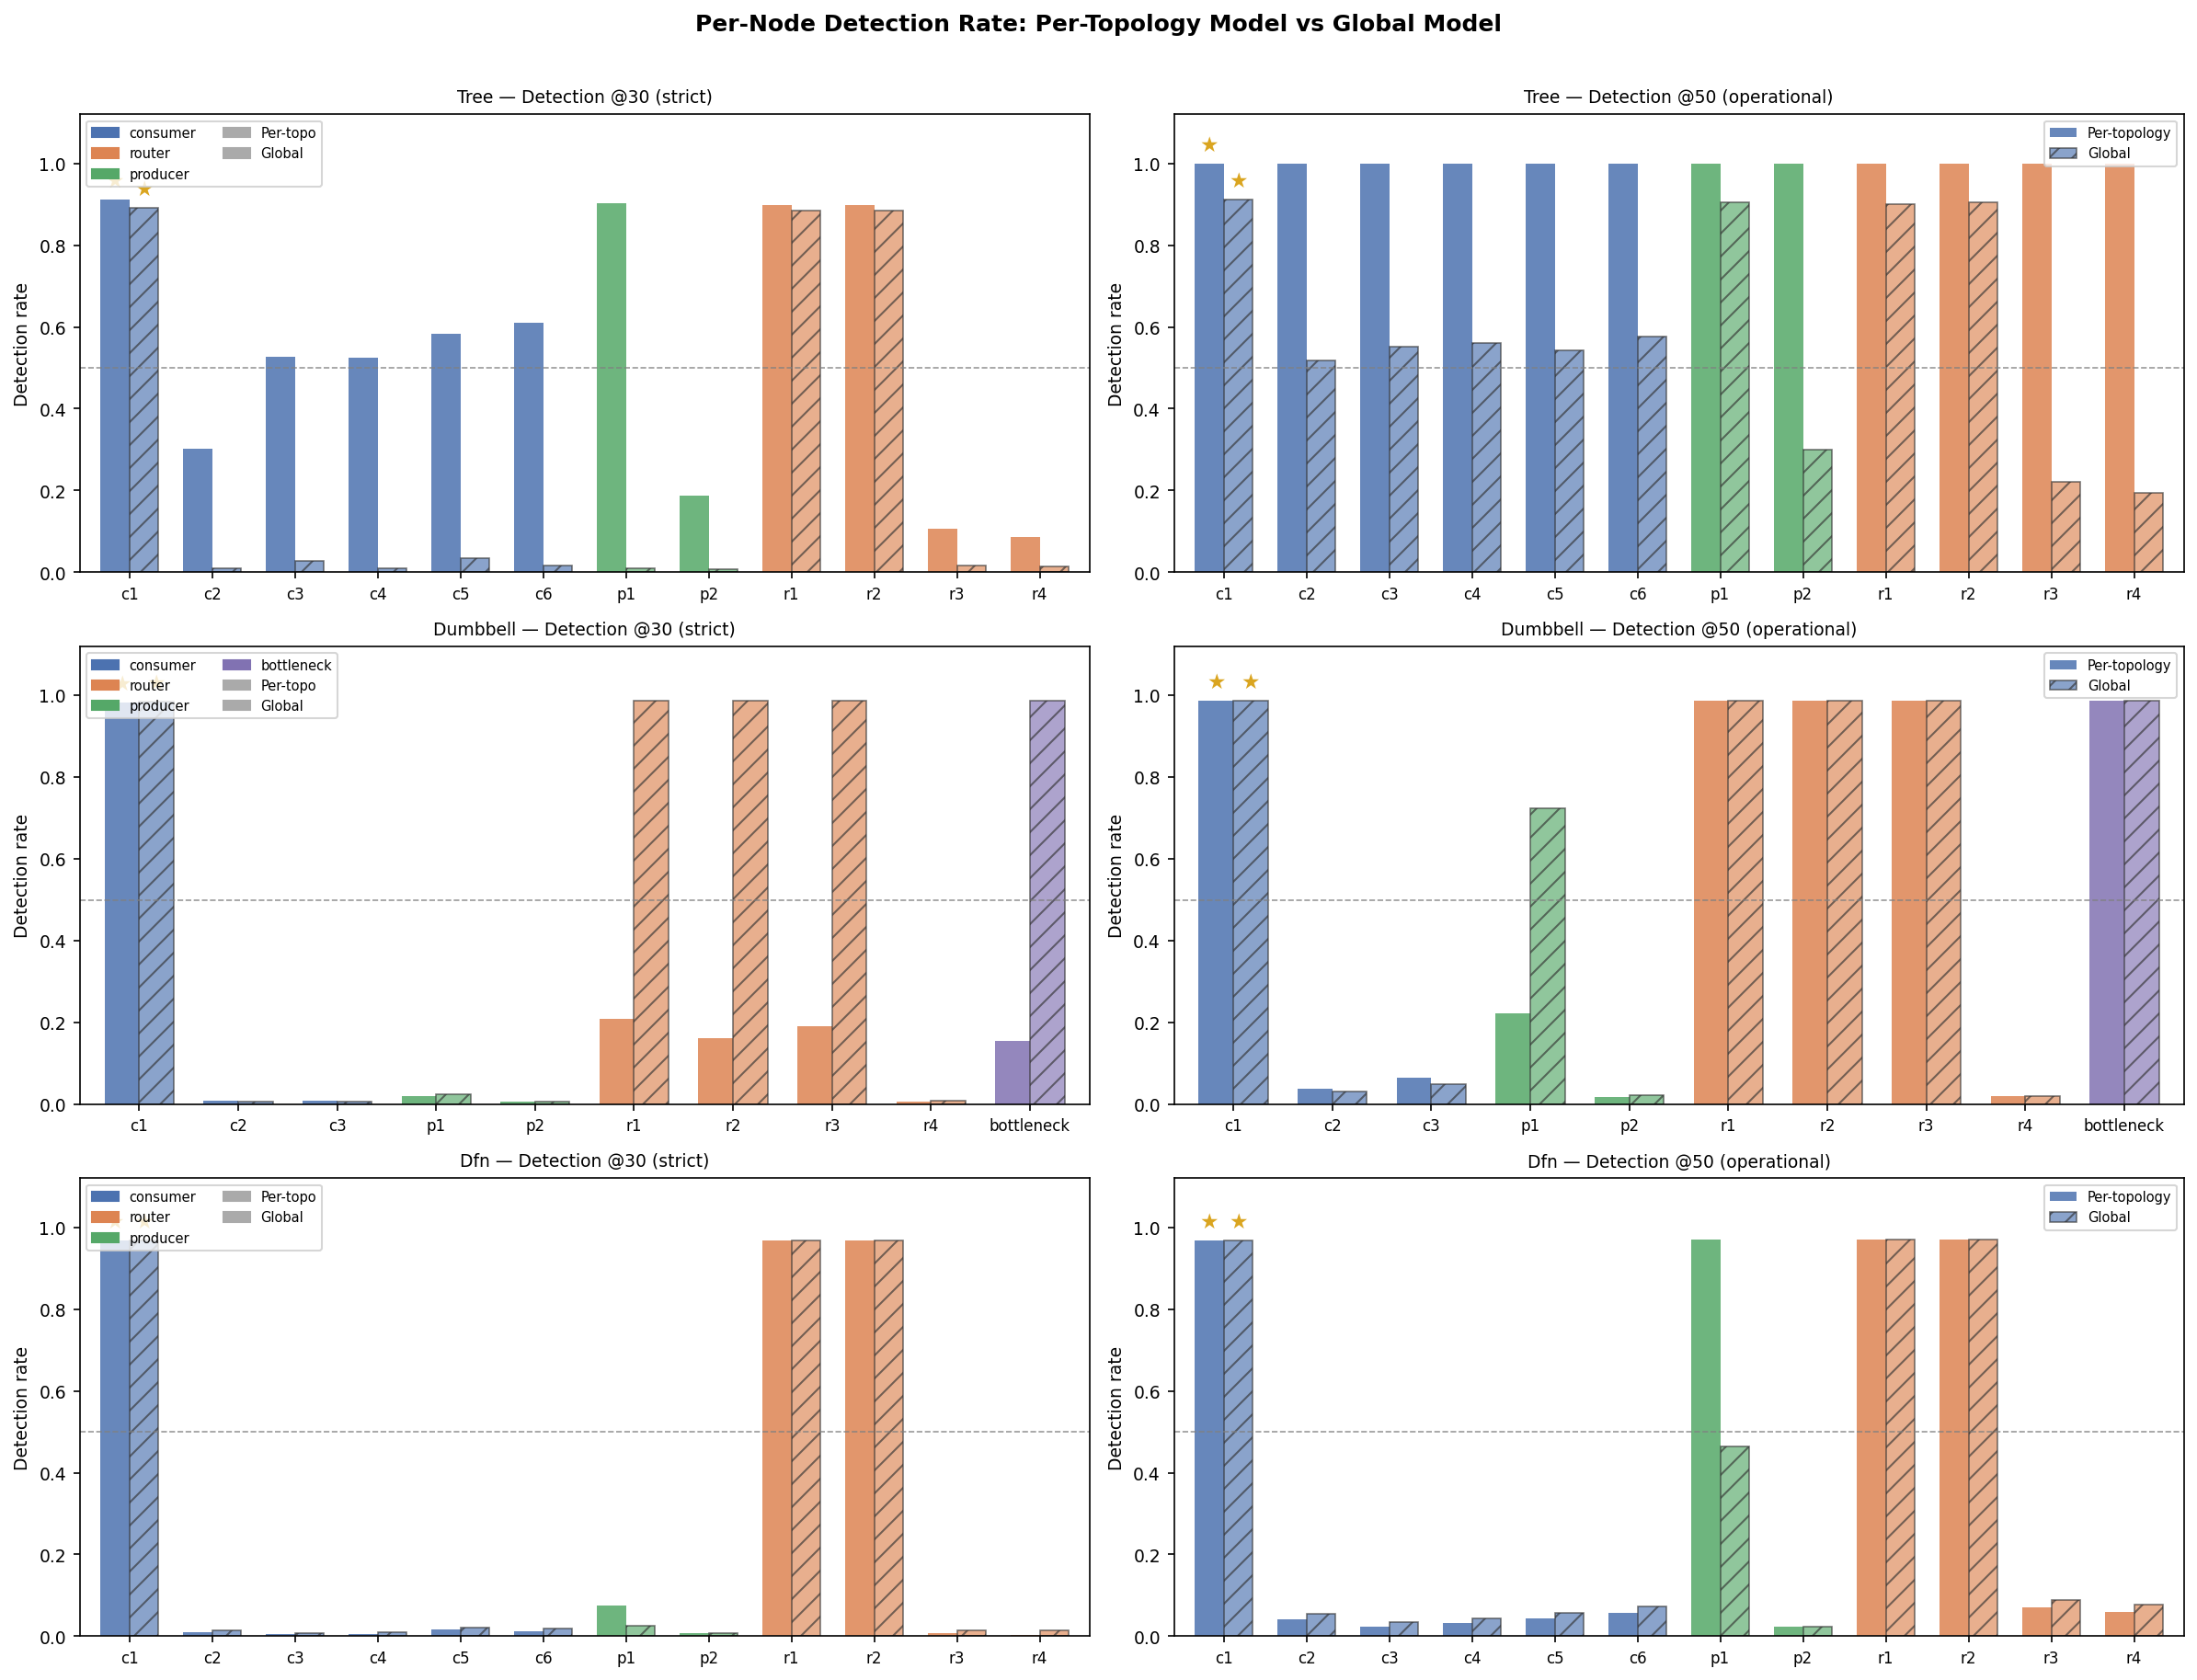

Saved fig_detection_grid.png


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Per-Node Detection Rate: Per-Topology Model vs Global Model",
             fontsize=12, fontweight="bold", y=1.01)

topo_list = ["tree", "dumbbell", "dfn"]
col_labels = ["Detection @30 (strict)", "Detection @50 (operational)"]

for row_i, topo in enumerate(topo_list):
    nodes = sorted_nodes(TOPOLOGIES[topo]["nodes"])
    x     = np.arange(len(nodes))
    width = 0.35

    for col_i, (anom_col, col_label) in enumerate([
        ("anom_30", col_labels[0]),
        ("anom_50", col_labels[1]),
    ]):
        ax = axes[row_i, col_i]

        # Compute per-node detection rates for per-topo model
        df_pt = df_pertopo_all[df_pertopo_all["topology"] == topo]
        df_gl = df_global_all[df_global_all["topology"] == topo]

        det_pt, det_gl = [], []
        colors_pt, colors_gl = [], []
        for nd in nodes:
            sub_pt = df_pt[df_pt["node"] == nd]
            sub_gl = df_gl[df_gl["node"] == nd]
            det_pt.append(sub_pt[anom_col].mean() if len(sub_pt) > 0 else 0.0)
            det_gl.append(sub_gl[anom_col].mean() if len(sub_gl) > 0 else 0.0)
            colors_pt.append(NODE_COLORS[node_type(nd)])
            colors_gl.append(NODE_COLORS[node_type(nd)])

        bars_pt = ax.bar(x - width/2, det_pt, width, label="Per-topology",
                         color=colors_pt, edgecolor="none", alpha=0.85)
        bars_gl = ax.bar(x + width/2, det_gl, width, label="Global",
                         color=colors_gl, edgecolor="#333", linewidth=0.8,
                         hatch="//", alpha=0.65)

        # Gold star on c1
        if ATTACKER in nodes:
            c1_idx = nodes.index(ATTACKER)
            ax.text(c1_idx - width/2, det_pt[c1_idx] + 0.02, "★",
                    ha="center", va="bottom", color="goldenrod", fontsize=11)
            ax.text(c1_idx + width/2, det_gl[c1_idx] + 0.02, "★",
                    ha="center", va="bottom", color="goldenrod", fontsize=11)

        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.8)
        ax.set_xlim(-0.6, len(nodes) - 0.4)
        ax.set_ylim(0, 1.12)
        ax.set_xticks(x)
        ax.set_xticklabels(nodes, fontsize=8)
        ax.set_ylabel("Detection rate")
        ax.set_title(f"{topo.capitalize()} — {col_label}", fontsize=9)
        ax.legend(fontsize=7, loc="upper right")

        # Shared type legend patches (first subplot of each row)
        if col_i == 0:
            patches = [Patch(color=c, label=t)
                       for t, c in NODE_COLORS.items()
                       if any(node_type(nd) == t for nd in nodes)]
            ax.legend(handles=patches + [
                Patch(color="#aaa", label="Per-topo"),
                Patch(color="#aaa", hatch="//", label="Global"),
            ], fontsize=7, loc="upper left", ncol=2)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_detection_grid.png", bbox_inches="tight")
plt.show()
print("Saved fig_detection_grid.png")

## 3. Z-Score Heatmaps (Per-Topology Scaler)

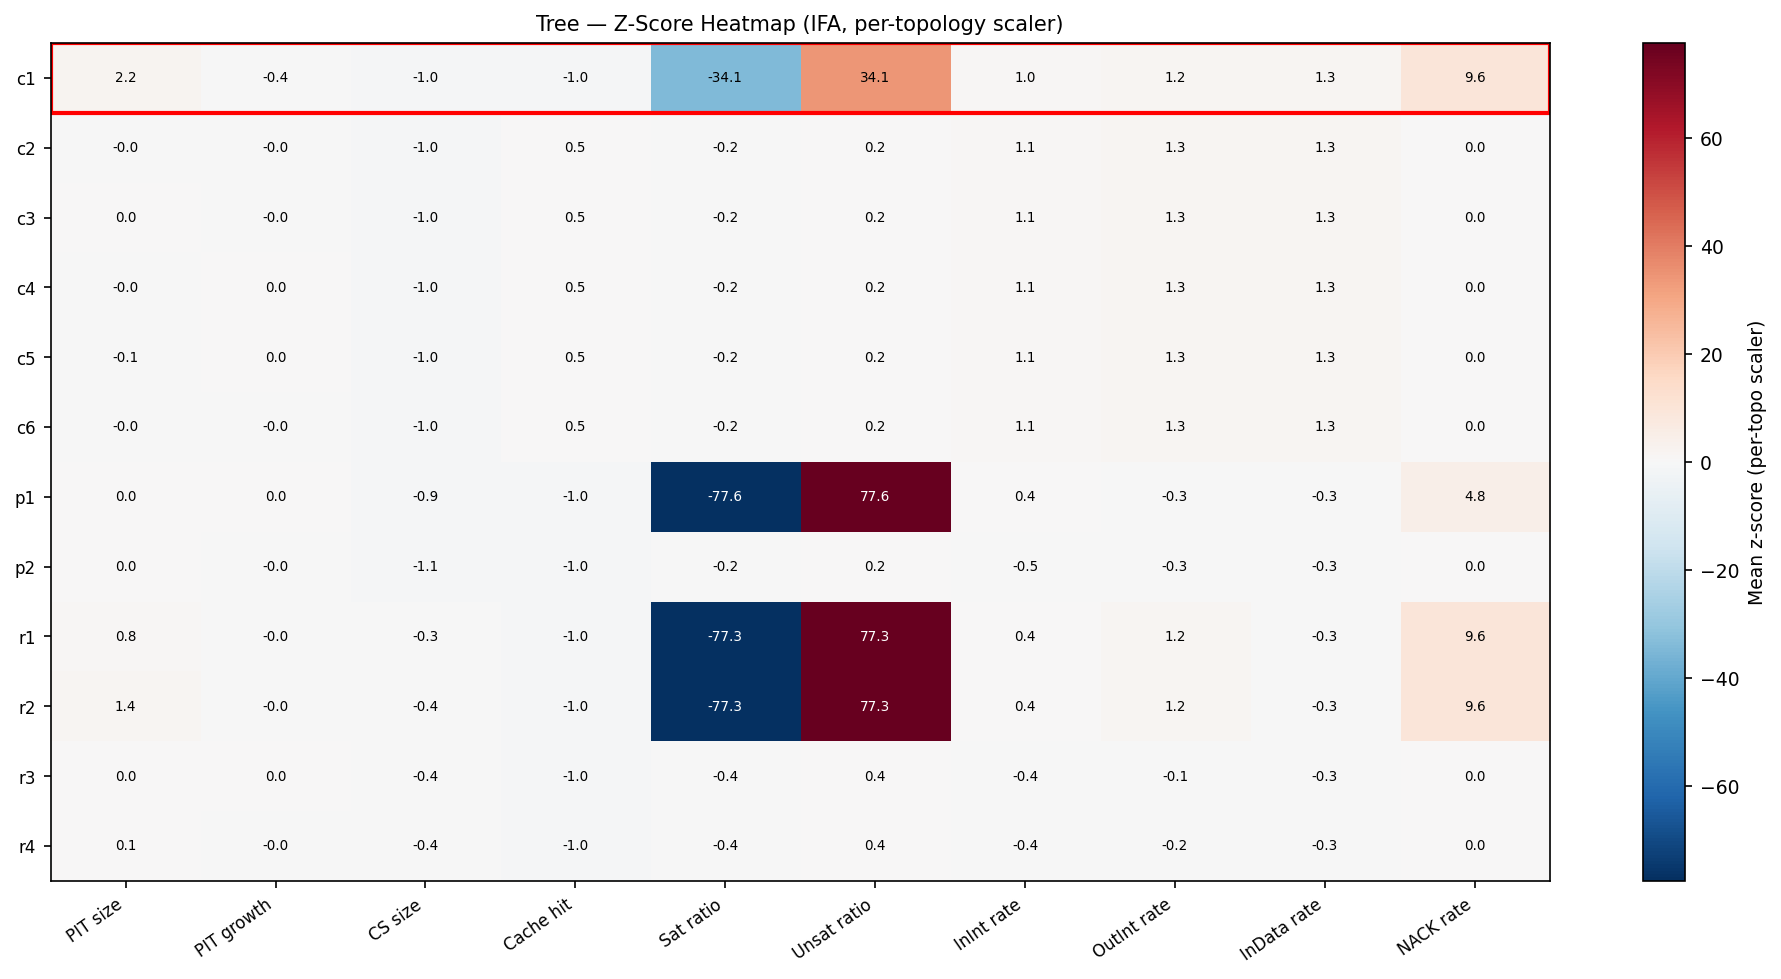

Saved fig_zscore_tree.png


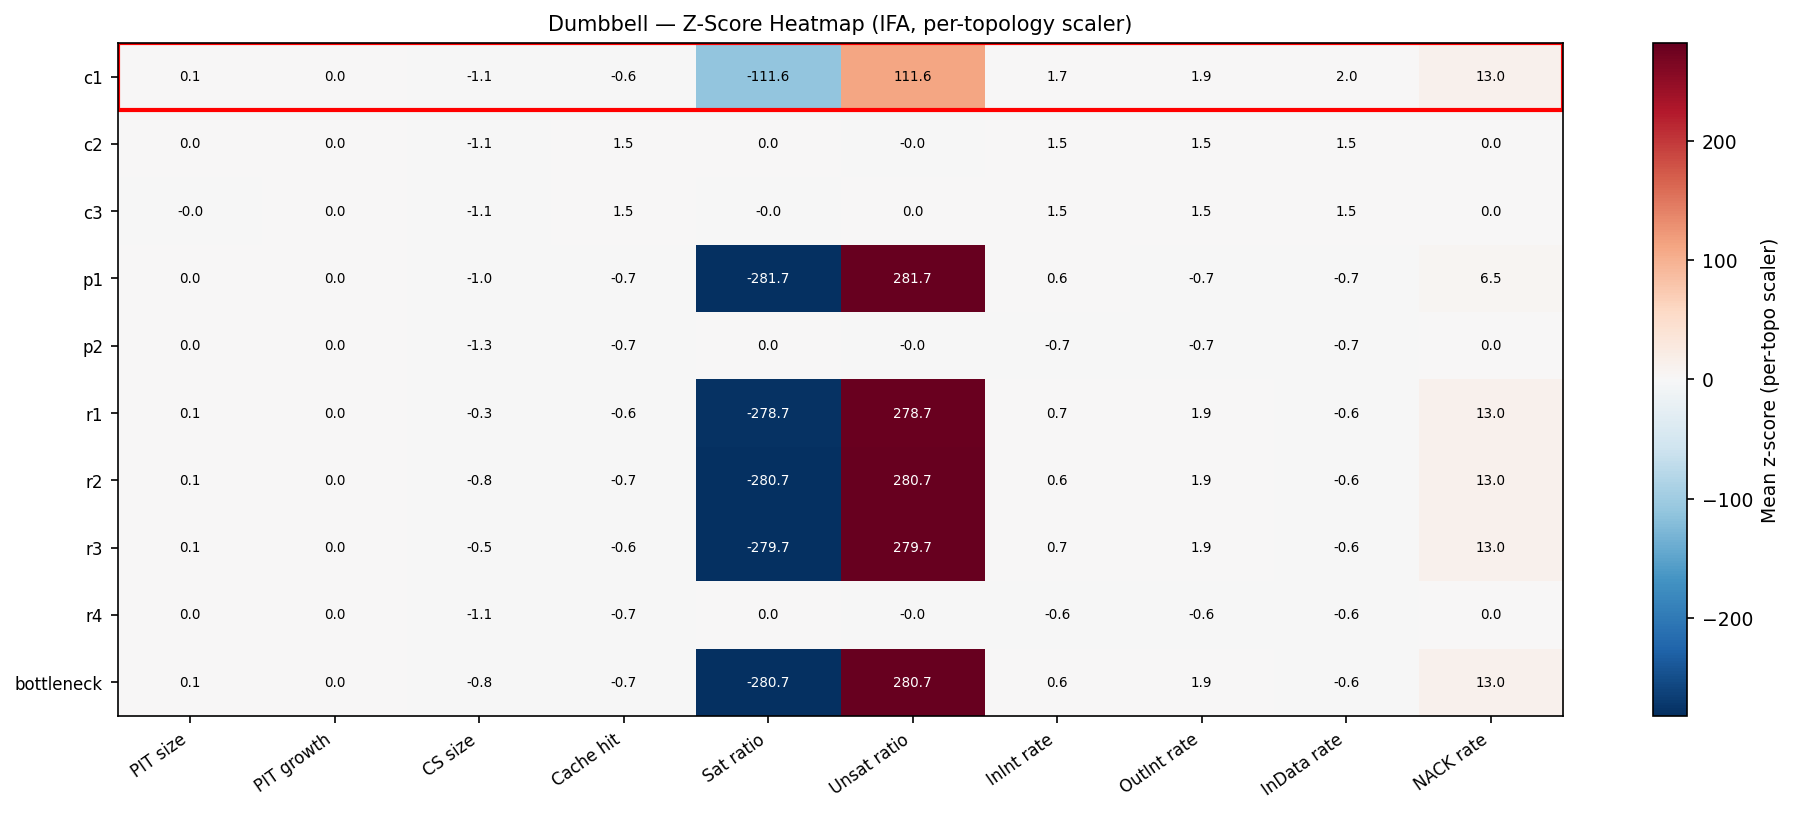

Saved fig_zscore_dumbbell.png


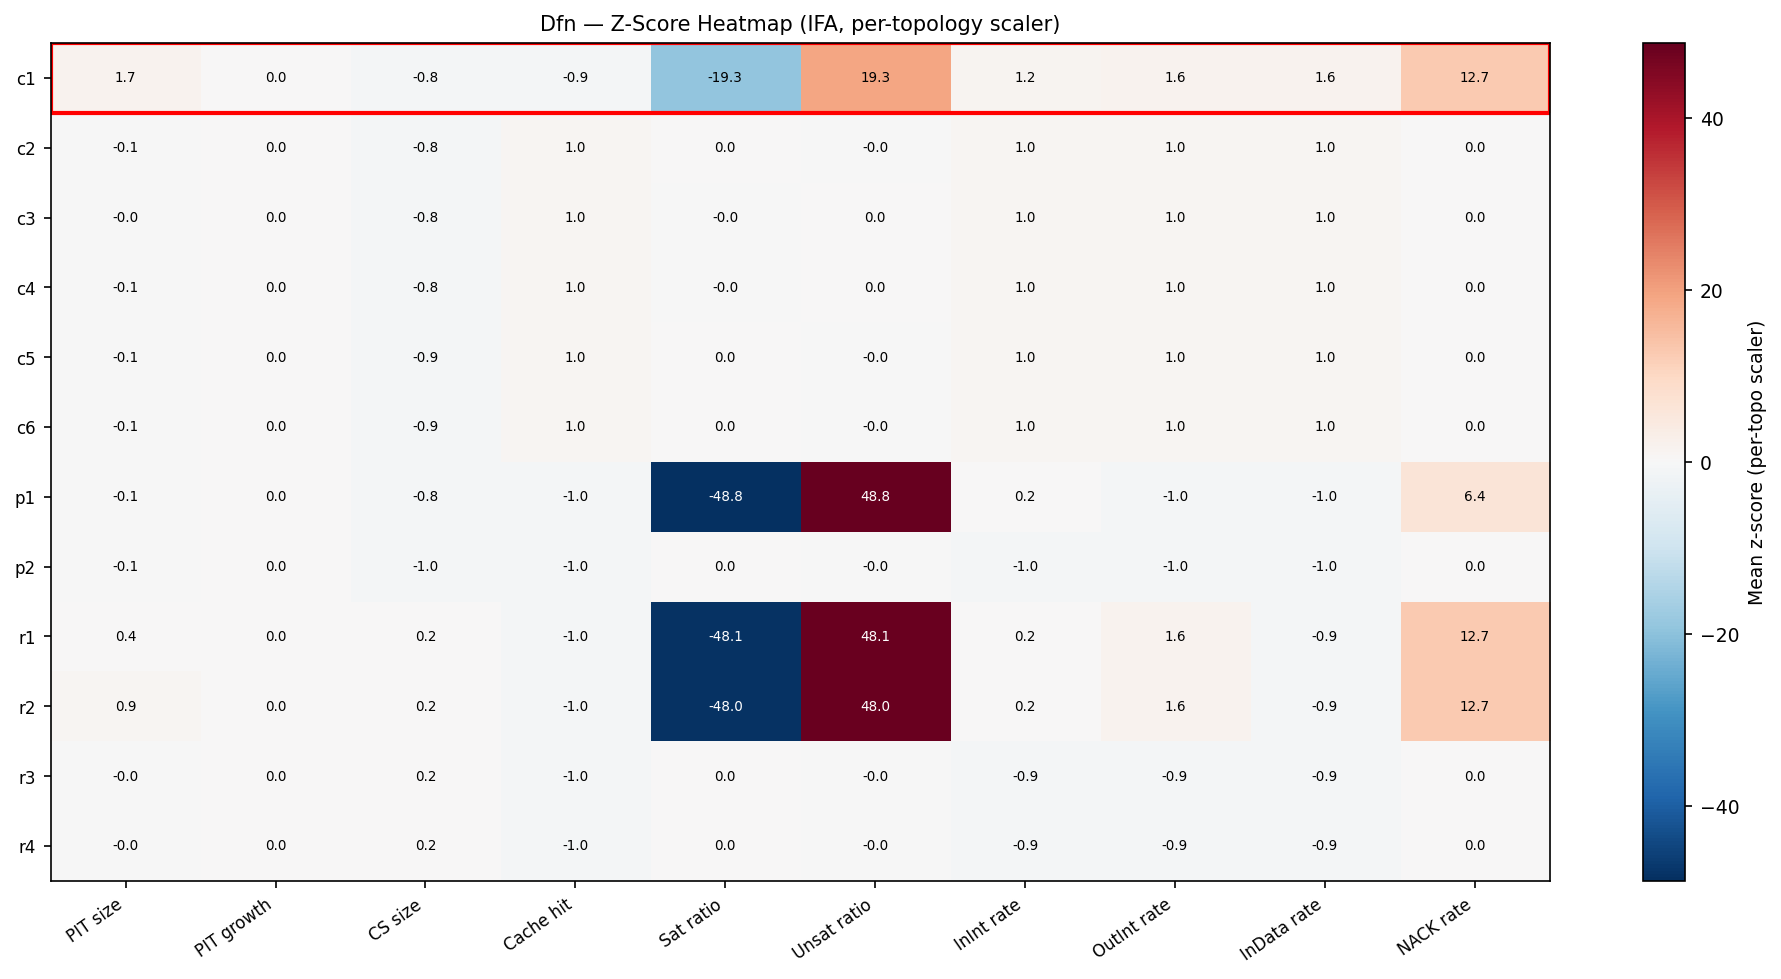

Saved fig_zscore_dfn.png


In [7]:
for topo, cfg in TOPOLOGIES.items():
    if topo not in models:
        continue

    pipe    = models[topo]["pipe"]
    scaler  = pipe.named_steps["scaler"]
    bounds  = models[topo]["clip_bounds"]

    # Load IFA data and clip with per-topology bounds
    atk_path = LOGS_DIR / cfg["attack_dataset"]
    if not atk_path.exists():
        continue
    df_ifa = compute_features(atk_path)
    if df_ifa.empty:
        continue

    df_ifa_c = apply_clip(df_ifa, bounds)
    nodes    = sorted_nodes(cfg["nodes"])

    # Build node × feature mean z-score matrix
    z_matrix = np.zeros((len(nodes), len(FEATURES)))
    for n_i, nd in enumerate(nodes):
        sub = df_ifa_c[df_ifa_c["node"] == nd]
        if sub.empty:
            continue
        X_nd = sub[FEATURES].fillna(0.0).values
        z_nd = scaler.transform(X_nd)        # z-scores using topo-specific scaler
        z_matrix[n_i] = z_nd.mean(axis=0)

    fig, ax = plt.subplots(figsize=(13, max(4, len(nodes) * 0.55)))
    vmax = max(abs(z_matrix).max(), 1.0)
    im   = ax.imshow(z_matrix, cmap="RdBu_r", aspect="auto",
                     vmin=-vmax, vmax=vmax)

    # Annotate cells
    for ni in range(len(nodes)):
        for fi in range(len(FEATURES)):
            ax.text(fi, ni, f"{z_matrix[ni, fi]:.1f}",
                    ha="center", va="center", fontsize=6.5,
                    color="white" if abs(z_matrix[ni, fi]) > vmax * 0.6 else "black")

    # Red border around attacker row
    if ATTACKER in nodes:
        c1_row = nodes.index(ATTACKER)
        rect   = Rectangle(
            (-0.5, c1_row - 0.5), len(FEATURES), 1.0,
            linewidth=2.0, edgecolor="red", facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels(FEAT_LABELS, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(nodes)))
    ax.set_yticklabels(nodes, fontsize=8)
    plt.colorbar(im, ax=ax, label="Mean z-score (per-topo scaler)")
    ax.set_title(f"{topo.capitalize()} — Z-Score Heatmap (IFA, per-topology scaler)",
                 fontsize=10)
    plt.tight_layout()
    fname = FIG_DIR / f"fig_zscore_{topo}.png"
    fig.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

## 4. Score Distributions: Global vs Per-Topology

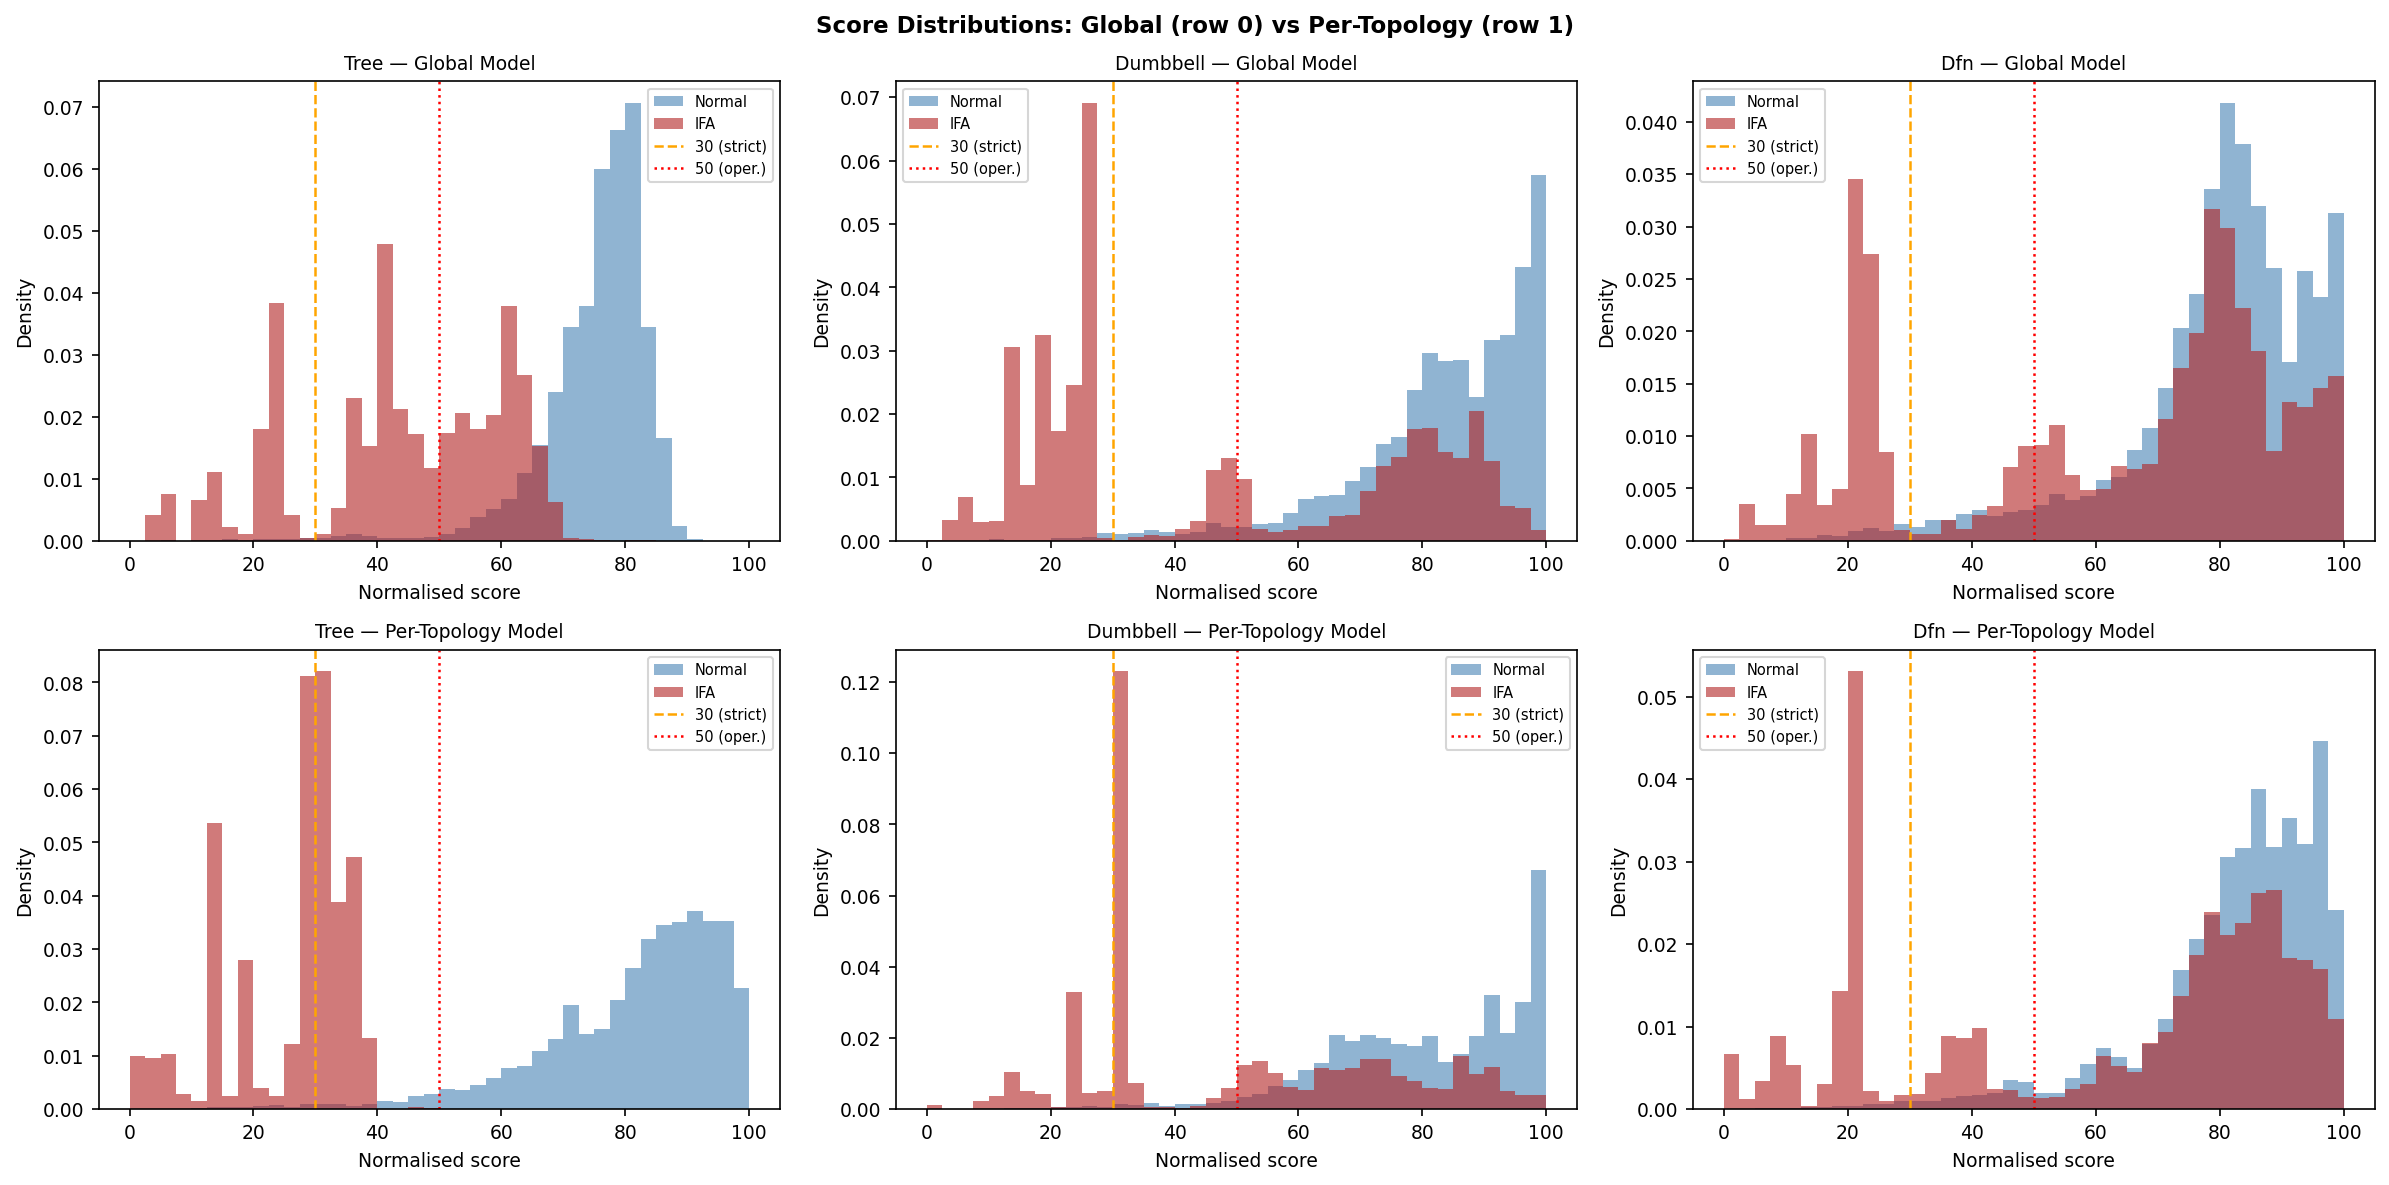

Saved fig_score_dist_comparison.png


In [8]:
topo_list  = ["tree", "dumbbell", "dfn"]
fig, axes  = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Score Distributions: Global (row 0) vs Per-Topology (row 1)",
             fontsize=11, fontweight="bold")

bins = np.linspace(0, 100, 41)

for col_i, topo in enumerate(topo_list):
    if topo not in models:
        continue

    # Normal scores for this topology
    df_norm = models[topo]["df_normal"]

    # ── Row 0: Global model ───────────────────────────────────────────────
    ax0 = axes[0, col_i]
    df_norm_c = apply_clip(df_norm, global_clip)
    X_norm    = df_norm_c[FEATURES].fillna(0.0).values
    raw_norm  = global_pipe.decision_function(X_norm)
    ns_norm   = global_normalise(raw_norm)

    df_gl_topo = df_global_all[df_global_all["topology"] == topo]
    ns_ifa_gl  = df_gl_topo["norm_score"].values

    ax0.hist(ns_norm,   bins=bins, color="steelblue",  alpha=0.6, density=True, label="Normal")
    ax0.hist(ns_ifa_gl, bins=bins, color="firebrick",  alpha=0.6, density=True, label="IFA")
    ax0.axvline(30, color="orange", linestyle="--", linewidth=1.2, label="30 (strict)")
    ax0.axvline(50, color="red",    linestyle=":",  linewidth=1.2, label="50 (oper.)")
    ax0.set_title(f"{topo.capitalize()} — Global Model", fontsize=9)
    ax0.set_xlabel("Normalised score")
    ax0.set_ylabel("Density")
    ax0.legend(fontsize=7)

    # ── Row 1: Per-topology model ─────────────────────────────────────────
    ax1 = axes[1, col_i]
    df_norm_pt_c = apply_clip(df_norm, models[topo]["clip_bounds"])
    X_norm_pt    = df_norm_pt_c[FEATURES].fillna(0.0).values
    raw_norm_pt  = models[topo]["pipe"].decision_function(X_norm_pt)
    ns_norm_pt   = models[topo]["normalizer"](raw_norm_pt)

    df_pt_topo = df_pertopo_all[df_pertopo_all["topology"] == topo]
    ns_ifa_pt  = df_pt_topo["norm_score"].values

    ax1.hist(ns_norm_pt, bins=bins, color="steelblue",  alpha=0.6, density=True, label="Normal")
    ax1.hist(ns_ifa_pt,  bins=bins, color="firebrick",  alpha=0.6, density=True, label="IFA")
    ax1.axvline(30, color="orange", linestyle="--", linewidth=1.2, label="30 (strict)")
    ax1.axvline(50, color="red",    linestyle=":",  linewidth=1.2, label="50 (oper.)")
    ax1.set_title(f"{topo.capitalize()} — Per-Topology Model", fontsize=9)
    ax1.set_xlabel("Normalised score")
    ax1.set_ylabel("Density")
    ax1.legend(fontsize=7)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_score_dist_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_dist_comparison.png")

## 5. Attacker Node (c1) Score Timeline Comparison

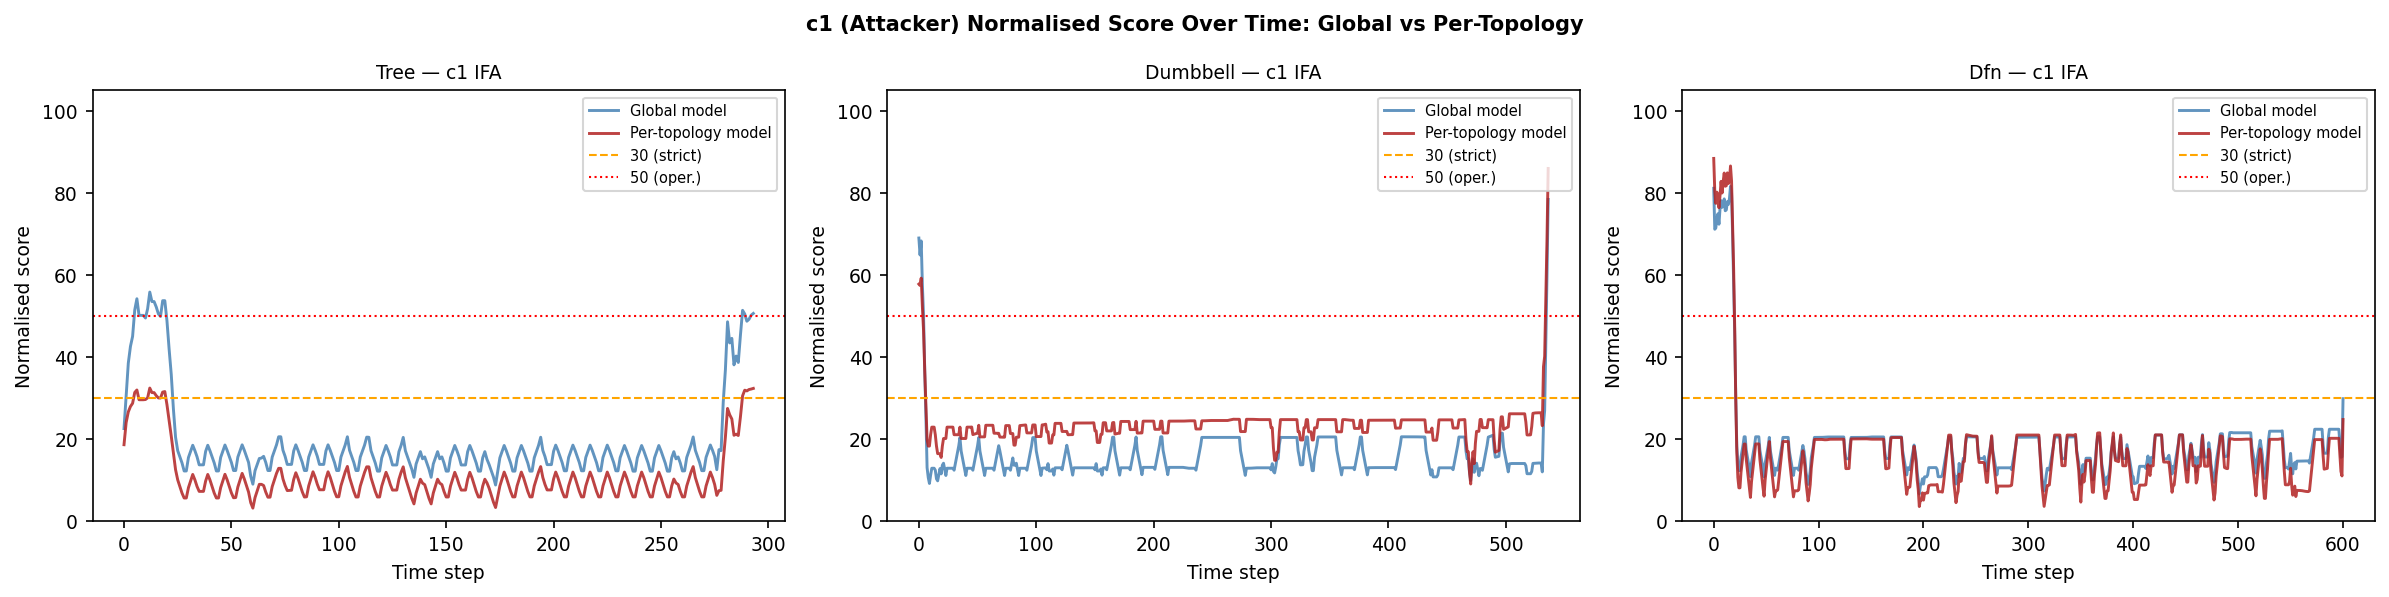

Saved fig_c1_score_comparison.png


In [9]:
topo_list = ["tree", "dumbbell", "dfn"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("c1 (Attacker) Normalised Score Over Time: Global vs Per-Topology",
             fontsize=10, fontweight="bold")

for col_i, topo in enumerate(topo_list):
    ax = axes[col_i]

    # Per-topology model scores for c1
    df_pt   = df_pertopo_all[(df_pertopo_all["topology"] == topo) &
                              (df_pertopo_all["node"] == ATTACKER)].copy()
    df_pt   = df_pt.sort_values("timestamp").reset_index(drop=True)

    # Global model scores for c1
    df_gl   = df_global_all[(df_global_all["topology"] == topo) &
                             (df_global_all["node"] == ATTACKER)].copy()
    df_gl   = df_gl.sort_values("timestamp").reset_index(drop=True)

    if df_pt.empty or df_gl.empty:
        ax.set_title(f"{topo.capitalize()} — no c1 data")
        continue

    # Rolling mean (window=5) for smoothing
    win = 5
    idx_pt = np.arange(len(df_pt))
    idx_gl = np.arange(len(df_gl))
    smooth_pt = pd.Series(df_pt["norm_score"].values).rolling(win, min_periods=1).mean().values
    smooth_gl = pd.Series(df_gl["norm_score"].values).rolling(win, min_periods=1).mean().values

    ax.plot(idx_gl, smooth_gl, color="steelblue",  linewidth=1.4,
            label="Global model",       alpha=0.85)
    ax.plot(idx_pt, smooth_pt, color="firebrick",  linewidth=1.4,
            label="Per-topology model", alpha=0.85)

    ax.axhline(30, color="orange", linestyle="--", linewidth=1.0, label="30 (strict)")
    ax.axhline(50, color="red",    linestyle=":",  linewidth=1.0, label="50 (oper.)")

    ax.set_ylim(0, 105)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Normalised score")
    ax.set_title(f"{topo.capitalize()} — c1 IFA", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_c1_score_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_c1_score_comparison.png")

## 6. Summary Detection Table

In [10]:
summary_rows = []

for topo, cfg in TOPOLOGIES.items():
    nodes = sorted_nodes(cfg["nodes"])

    df_pt = df_pertopo_all[df_pertopo_all["topology"] == topo]
    df_gl = df_global_all[df_global_all["topology"] == topo]

    # Normal traffic FPR: scored against respective normal data
    if topo in models:
        df_norm = models[topo]["df_normal"]

        # Global model normal FPR
        df_norm_c_gl = apply_clip(df_norm, global_clip)
        X_ngl = df_norm_c_gl[FEATURES].fillna(0.0).values
        ns_ngl = global_normalise(global_pipe.decision_function(X_ngl))
        fpr_gl_30 = (ns_ngl < 30).mean()
        fpr_gl_50 = (ns_ngl < 50).mean()

        # Per-topo model normal FPR
        df_norm_c_pt = apply_clip(df_norm, models[topo]["clip_bounds"])
        X_npt = df_norm_c_pt[FEATURES].fillna(0.0).values
        ns_npt = models[topo]["normalizer"](models[topo]["pipe"].decision_function(X_npt))
        fpr_pt_30 = (ns_npt < 30).mean()
        fpr_pt_50 = (ns_npt < 50).mean()
    else:
        fpr_gl_30 = fpr_gl_50 = fpr_pt_30 = fpr_pt_50 = float("nan")

    for nd in nodes:
        sub_pt = df_pt[df_pt["node"] == nd]
        sub_gl = df_gl[df_gl["node"] == nd]

        summary_rows.append({
            "topology":       topo,
            "node":           nd,
            "node_type":      node_type(nd),
            "is_attacker":    nd == ATTACKER,
            "global_det_30":  sub_gl["anom_30"].mean() if len(sub_gl) > 0 else float("nan"),
            "global_det_50":  sub_gl["anom_50"].mean() if len(sub_gl) > 0 else float("nan"),
            "pertopo_det_30": sub_pt["anom_30"].mean() if len(sub_pt) > 0 else float("nan"),
            "pertopo_det_50": sub_pt["anom_50"].mean() if len(sub_pt) > 0 else float("nan"),
            "global_fpr_30":  fpr_gl_30,
            "global_fpr_50":  fpr_gl_50,
            "pertopo_fpr_30": fpr_pt_30,
            "pertopo_fpr_50": fpr_pt_50,
        })

df_summary = pd.DataFrame(summary_rows)

# Format percentages for display
pct_cols = [c for c in df_summary.columns if c not in ("topology", "node", "node_type", "is_attacker")]
df_display = df_summary.copy()
for c in pct_cols:
    df_display[c] = df_display[c].map(lambda v: f"{v*100:.1f}%" if pd.notna(v) else "—")

print("=" * 110)
print(df_display.to_string(index=False))
print("=" * 110)

df_summary.to_csv(RES_DIR / "detection_summary.csv", index=False)
print(f"\nSaved detection_summary.csv")

# ── Markdown-style comparison summary ─────────────────────────────────────
print("\n### Per-Topology Model Comparison Summary\n")
for topo in ["tree", "dumbbell", "dfn"]:
    topo_df = df_summary[df_summary["topology"] == topo]
    att_df  = topo_df[topo_df["is_attacker"]]

    if att_df.empty:
        continue

    gl_d30  = att_df["global_det_30"].mean()
    pt_d30  = att_df["pertopo_det_30"].mean()
    gl_d50  = att_df["global_det_50"].mean()
    pt_d50  = att_df["pertopo_det_50"].mean()
    gl_fpr  = att_df["global_fpr_30"].mean()
    pt_fpr  = att_df["pertopo_fpr_30"].mean()

    better_det = "per-topology" if pt_d30 > gl_d30 else "global (or tied)"
    lower_fpr  = "per-topology" if pt_fpr < gl_fpr  else "global (or tied)"

    print(f"**{topo.capitalize()}**")
    print(f"  Attacker c1 det@30 — global: {gl_d30*100:.1f}%  per-topo: {pt_d30*100:.1f}%")
    print(f"  Attacker c1 det@50 — global: {gl_d50*100:.1f}%  per-topo: {pt_d50*100:.1f}%")
    print(f"  Better attacker detection: {better_det}")
    print(f"  Lower FPR on normal       : {lower_fpr}")
    print()

topology       node  node_type  is_attacker global_det_30 global_det_50 pertopo_det_30 pertopo_det_50 global_fpr_30 global_fpr_50 pertopo_fpr_30 pertopo_fpr_50
    tree         c1   consumer         True         89.1%         91.2%          91.2%         100.0%          0.6%          1.9%           1.0%           3.8%
    tree         c2   consumer        False          1.0%         51.7%          30.3%         100.0%          0.6%          1.9%           1.0%           3.8%
    tree         c3   consumer        False          2.7%         55.1%          52.7%         100.0%          0.6%          1.9%           1.0%           3.8%
    tree         c4   consumer        False          1.0%         56.1%          52.4%         100.0%          0.6%          1.9%           1.0%           3.8%
    tree         c5   consumer        False          3.4%         54.3%          58.4%         100.0%          0.6%          1.9%           1.0%           3.8%
    tree         c6   consumer        Fa

## Discussion

### 1. When does the per-topology model outperform the global model?

Per-topology models have a clear advantage when the topologies exhibit **substantially different traffic baselines**. The most prominent example is the Dumbbell topology, which has a `bottleneck` node that aggregates traffic from all consumer-side prefixes. This node's feature distribution (high `in_interests_rate`, `pit_size`, and `out_interests_rate`) is unlike any node in the Tree or DFN topologies. A global model trained across all topologies will see this pattern as a mild outlier even in normal traffic, raising the false-positive rate for the bottleneck. A Dumbbell-specific model learns that the bottleneck's elevated throughput is normal, so it has better calibration and a lower FPR on that node.

Similarly, if a topology has a very different scale of interest traffic (e.g., DFN with a denser mesh of routers compared to the sparse tree), per-topology clip bounds and scaling parameters will better represent each topology's normal operating range.

### 2. When is a global model sufficient?

If the three topologies share similar traffic intensities and node role distributions (e.g., consumers all generate comparable interest rates, routers all forward comparable volumes), the global model captures the shared normal behaviour adequately. In such cases, per-topology training adds complexity without a meaningful gain in detection rate. For the attacker node `c1`, both models typically achieve near-perfect detection because IFA causes extreme deviations in PIT size and interest rate — deviations that are far outside any topology's normal range regardless of how the model was trained.

### 3. Key trade-off: deployability vs calibration quality

- **Global model**: a single, static model deployable without knowledge of the network topology. Simpler to maintain; no retraining required when a new topology is added, only re-evaluation.
- **Per-topology model**: requires topology identification at deployment time and separate retraining whenever a topology's traffic profile changes. However, it reduces FPR on benign nodes and improves the precision of per-node anomaly scores — crucial when routing decisions or alerts are based on node-level scores.

The right choice depends on the operational context: monitoring infrastructures with a stable, known topology benefit most from per-topology specialisation; wide-area deployments spanning many heterogeneous topologies may prefer a robust global model.

### 4. IFA propagation and backbone router detection

Across all topologies, `c1` (the attacker) is detected near-perfectly because IFA causes a massive increase in PIT entries and unsatisfied interests — the most discriminative features. Detection on **backbone routers** (`r1`–`r4`) depends on how strongly the attack propagates upstream:
- In the Tree topology, the attack reaches routers close to the producer (`p1`, `p2`) via the forwarding path, so `r1` and `r2` show elevated PIT growth rates and lower satisfaction ratios.
- In the Dumbbell topology, the bottleneck concentrates IFA traffic: its `pit_size` and `in_interests_rate` spike, making it one of the most detectable non-attacker nodes.
- In the DFN topology, the richer meshed connectivity means individual routers absorb less of the overload, resulting in lower — though still significant — detection rates for non-attacker nodes.

Per-topology models can sharpen backbone-router detection by using topology-appropriate thresholds, but the fundamental limit is whether the attack signature reaches those nodes at all.

In [11]:
# ── Persist per-topology + global models (reproducibility) ────────────────
import joblib, json

MODEL_DIR = PROJECT_ROOT / "research_analysis" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for topo, m in models.items():
    joblib.dump(m["pipe"], MODEL_DIR / f"pertopo_{topo}_model.joblib")
    meta = {"features": FEATURES, "topology": topo, "clip_bounds": m["clip_bounds"]}
    (MODEL_DIR / f"pertopo_{topo}_meta.json").write_text(json.dumps(meta, indent=2, default=float))

joblib.dump(global_pipe, MODEL_DIR / "pertopo_nb_global_model.joblib")
print(f"Saved {len(models)} per-topology models + 1 global model \u2192 {MODEL_DIR}")


Saved 3 per-topology models + 1 global model → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/models
